=============================================================
# **Customer Segmentation for a Retail Mall**
### Using K-Means Clustering to Identify Distinct Customer Groups
=============================================================


-----------------------------------------------------------
## Business Problem
-----------------------------------------------------------

A shopping mall wants to run targeted marketing campaigns instead of 
sending the same offer to every customer. Right now, they treat all 
200 customers as one group — which wastes budget on discounts for 
customers who would've spent anyway, and misses customers who need 
more encouragement to spend.

**Goal:** Segment customers into distinct groups based on their 
annual income and spending behavior, so the marketing team can design 
a different strategy for each group (e.g., loyalty rewards for high 
spenders, discount offers for price-sensitive customers).

**Business question we're answering:** 
"How many natural customer types exist in our data, and what defines each one?"

## About the Data
- Dataset: Mall Customers (200 records)
- Source: Mall membership card data
- Features: CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
mall_customers = pd.read_csv('./data/Mall_Customers.csv')

In [3]:
mall_customers.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
mall_customers.shape

(200, 5)

In [5]:
mall_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


-----------------------------------------------------------
## Data Preprocessing
-----------------------------------------------------------


In [6]:
# Handle missing values
mall_customers.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
# Handle duplicate rows
mall_customers.duplicated().sum()

np.int64(0)

Nothing to handle in duplicates and nulls.

In [8]:
# Drop irrelevant columns
# CustomerID is just a row identifier — it carries no behavioral meaning
mall_customers = mall_customers.drop('CustomerID', axis = 1)

In [9]:
# Fix column names/types
mall_customers = mall_customers.rename(columns={'Genre': 'Gender', 'Annual Income (k$)': 'Annual_Income_k', 'Spending Score (1-100)': 'Spending_Score'})

In [10]:
# Handle categorical variables
mall_customers['Gender'] = mall_customers['Gender'] .map({'Male':0, "Female":1})

In [11]:
# We keep a text version (Gender_Label) separately for readable charts/reports.
mall_customers['Gender_Label'] = mall_customers['Gender'].map({0:'Male', 1: 'Female'})

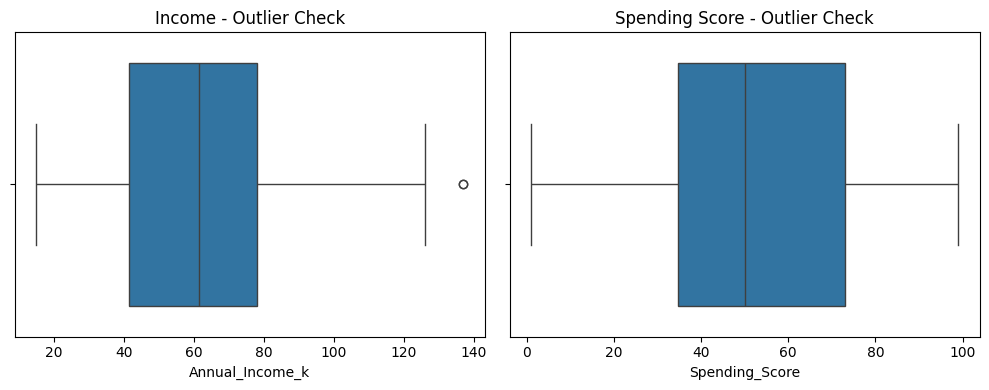

In [12]:
# Detect and handle outliers
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x = mall_customers['Annual_Income_k'])
plt.title('Income - Outlier Check')

plt.subplot(1,2,2)
sns.boxplot(x = mall_customers['Spending_Score'])
plt.title('Spending Score - Outlier Check')

plt.tight_layout()
plt.savefig('outputs/outlier_check.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Investigating the flagged outlier(s) using the IQR method
Q1 = mall_customers['Annual_Income_k'].quantile(0.25)
Q3 = mall_customers['Annual_Income_k'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

income_outliers = mall_customers[
    (mall_customers['Annual_Income_k'] < lower_bound) |
    (mall_customers['Annual_Income_k'] > upper_bound)
]
print(income_outliers[['Age', 'Gender_Label', 'Annual_Income_k', 'Spending_Score']])

     Age Gender_Label  Annual_Income_k  Spending_Score
198   32         Male              137              18
199   30         Male              137              83


**DECISION**: We keep these outliers.   
They are two genuinely high-income customers (137k), not data entry errors.
One spends a lot (Spending_Score 83), one barely spends (Spending_Score 18) —
this is exactly the kind of behavioral split the mall wants to know about.
Removing real, meaningful data points would hide useful business insight,
so we only remove outliers when they are clearly mistakes, not just rare.
 

-----------------------------------------------------------
## Exploratory Data Analysis
-----------------------------------------------------------

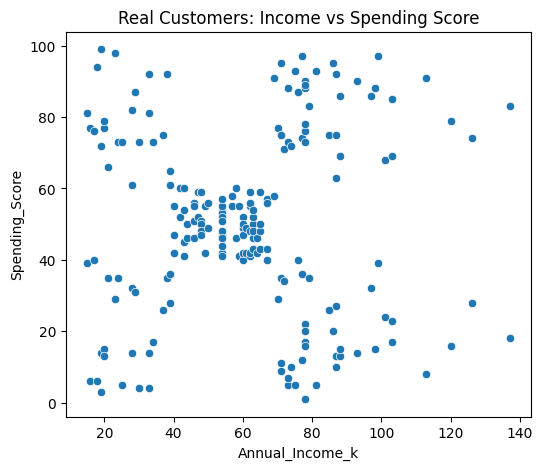

In [14]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=mall_customers, x = 'Annual_Income_k', y = 'Spending_Score')
plt.title('Real Customers: Income vs Spending Score')
plt.savefig('outputs/eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
mall_customers.describe()

,Gender,Age,Annual_Income_k,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,0.560000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,1.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


-----------------------------------------------------------
## Preparing Data for Clustering
-----------------------------------------------------------
K-Means measures distance between points, so features need to be on 
the same scale before we cluster — otherwise the feature with the
larger numeric range would unfairly dominate distance calculations.
 

In [16]:
# Selecting features and scaling
X = mall_customers[['Annual_Income_k', 'Spending_Score']]

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

-----------------------------------------------------------
## Choosing Number of Segments (Elbow Method)
-----------------------------------------------------------
We use the Elbow Method to decide how many customer groups actually 
exist in the data, rather than guessing.

In [18]:
inertia = []
k_range = range(1,11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

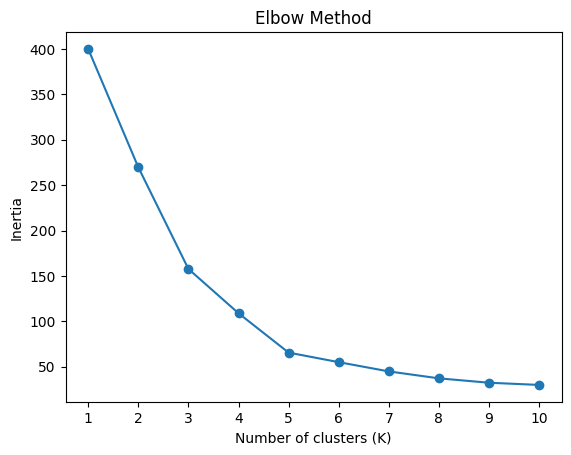

In [19]:
plt.plot(k_range, inertia , marker = 'o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.savefig('outputs/elbow_plot.png', dpi = 150, bbox_inches = 'tight')
plt.show()


-----------------------------------------------------------
## Validating Cluster Quality: Silhouette Score
-----------------------------------------------------------
The Elbow Method tells us where inertia stops improving much. The 
Silhouette Score adds a second, independent check — it tells us how 
well-separated and distinct the clusters actually are, helping confirm 
our choice of K.    
Higher score = better-separated clusters (range -1 to 1).

In [20]:
silhouette_scores = []
k_range_sil = range(2,11)       # silhouette score needs at least 2 clusters, so we start at 2, not 1

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

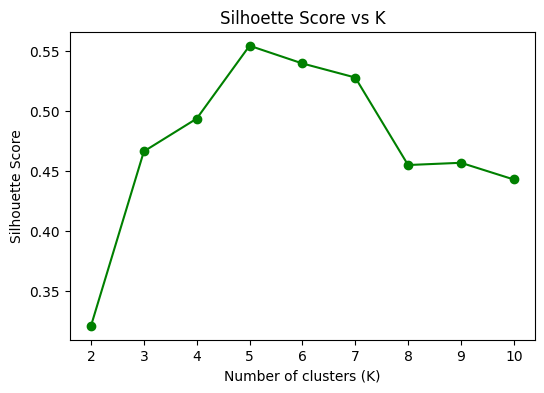

{1: np.float64(0.321), 2: np.float64(0.467), 3: np.float64(0.494), 4: np.float64(0.555), 5: np.float64(0.54), 6: np.float64(0.528), 7: np.float64(0.455), 8: np.float64(0.457), 9: np.float64(0.443)}


In [21]:
plt.figure(figsize=(6,4))
plt.plot(k_range_sil, silhouette_scores, marker = 'o', color = 'green')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhoette Score vs K")
plt.xticks(k_range_sil)
plt.savefig('outputs/silhouette_score.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print(dict(zip(k_range, [round(s, 3) for s in silhouette_scores])))

#### Combined View: Elbow Method vs Silhouette Score
Viewing both metrics side by side makes it easy to see they agree on 
K=5 as the optimal number of clusters.

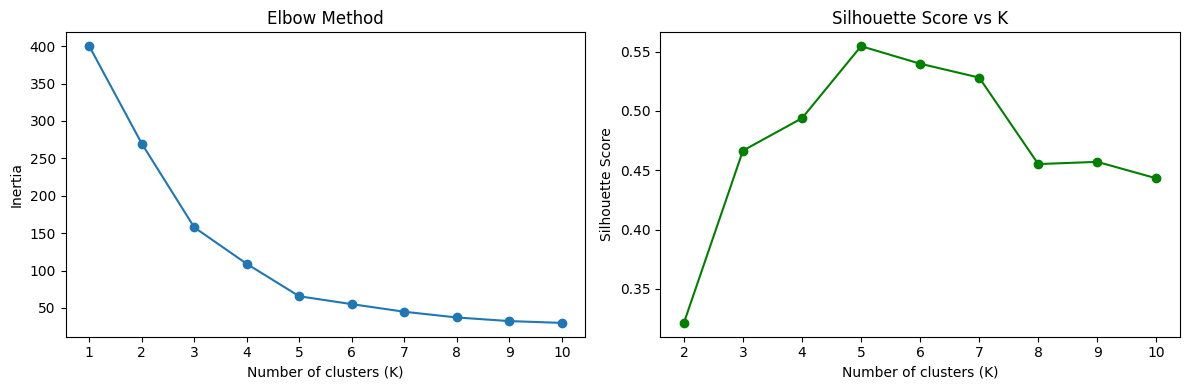

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left subplot: Elbow Method
axes[0].plot(k_range, inertia, marker='o')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(k_range)

# Right subplot: Silhouette Score
axes[1].plot(k_range_sil, silhouette_scores, marker='o', color='green')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xticks(k_range_sil)

plt.tight_layout()
plt.savefig('outputs/elbow_silhouette_combined.png', dpi=150, bbox_inches='tight')
plt.show()

**CONCLUSION**: Elbow method shows inertia improvement collapsing after K=5,    
and K=5 also has the highest silhouette score (~0.55). Both methods agree,
so we lock in final_k = 5 with confidence.
 

-----------------------------------------------------------
## Building the Segmentation Model
-----------------------------------------------------------

In [22]:
final_k = 5
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init= 10)
mall_customers['Cluster'] = kmeans.fit_predict(X_scaled)

-----------------------------------------------------------
## Visualizing Customer Segments
-----------------------------------------------------------

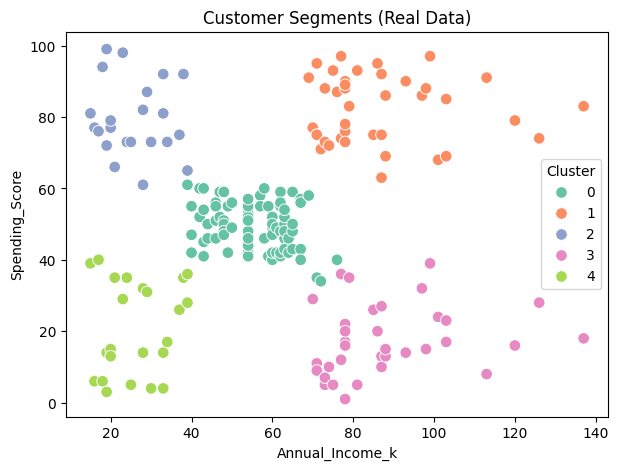

In [23]:
plt.figure(figsize=(7,5))
sns.scatterplot(data = mall_customers, x = "Annual_Income_k", y = 'Spending_Score', hue = 'Cluster', palette='Set2', s = 70)
plt.title("Customer Segments (Real Data)")
plt.savefig('outputs/cluster_plot.png', dpi=150, bbox_inches='tight')
plt.show()

-----------------------------------------------------------
## Cross-Segment Analysis: Age & Gender Patterns
-----------------------------------------------------------
Beyond behavioral clusters, we examine whether spending is influenced 
by age or gender — this helps design targeted messaging within each segment.

#### --- Age group spending ---

In [24]:
bins = [18, 25, 35, 45, 55, 70]
labels = ['18-25', '26-35', '36-45', '46-55', '56-70']
mall_customers['Age_Group'] = pd.cut(mall_customers['Age'], bins = bins, labels = labels)

age_spending = mall_customers.groupby('Age_Group', observed = True)['Spending_Score'].mean().round(1)
print(age_spending)

Age_Group
18-25    54.4
26-35    64.4
36-45    44.8
46-55    36.7
56-70    38.4
Name: Spending_Score, dtype: float64


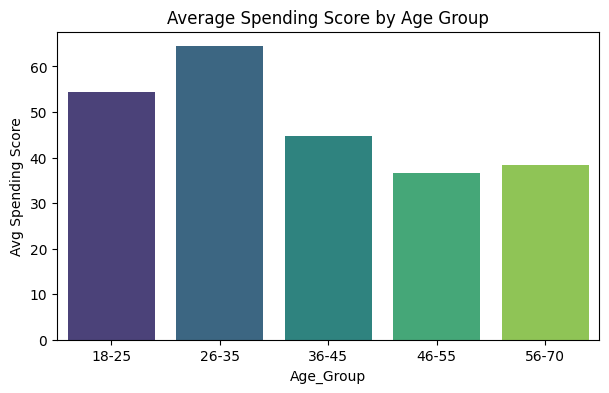

In [25]:
plt.figure(figsize=(7,4))
sns.barplot(x=age_spending.index, y=age_spending.values, hue=age_spending.index,
            palette='viridis', legend=False)
plt.title('Average Spending Score by Age Group')
plt.ylabel('Avg Spending Score')
plt.savefig('outputs/age_spending.png', dpi = 150, bbox_inches = 'tight')
plt.show()

#### --- Gender spending ---

In [26]:
gender_spending = mall_customers.groupby('Gender_Label')['Spending_Score'].mean().round(1)
print(gender_spending)

Gender_Label
Female    51.5
Male      48.5
Name: Spending_Score, dtype: float64


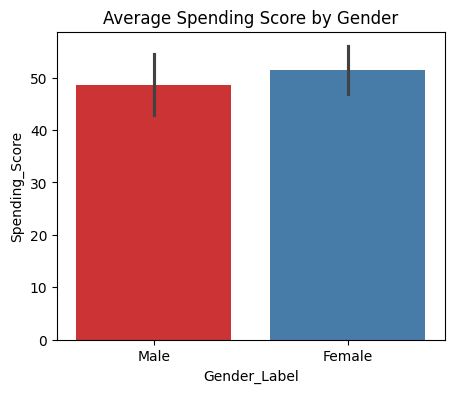

In [27]:
plt.figure(figsize=(5,4))
sns.barplot(x='Gender_Label', y='Spending_Score', data=mall_customers, palette='Set1', hue = 'Gender_Label', legend=False)
plt.title('Average Spending Score by Gender')
plt.savefig('outputs/gender_spending.png', dpi=150, bbox_inches='tight')
plt.show()

#### --- Combined cluster persona table ---

In [28]:
cluster_profile = mall_customers.groupby('Cluster').agg({
    'Age' : 'mean',
    'Annual_Income_k': 'mean',
    'Spending_Score' : 'mean',
    'Gender_Label' : lambda x : x.mode()[0]
}).round(1)
print(cluster_profile)

          Age  Annual_Income_k  Spending_Score Gender_Label
Cluster                                                    
0        42.7             55.3            49.5       Female
1        32.7             86.5            82.1       Female
2        25.3             25.7            79.4       Female
3        41.1             88.2            17.1         Male
4        45.2             26.3            20.9       Female


-----------------------------------------------------------
## Business Insights & Recommendations
-----------------------------------------------------------

## Business Insights & Recommendations

Based on the cluster_profile table above, I identified 5 distinct customer segments:

**Cluster 0 – Standard Customers** (Age ~43, Income 55k, Spending Score 49.5, mostly Female)
Moderate income and moderate spending — behaving as expected for their income level.
- Action: Standard seasonal promotions, loyalty points to nudge them slightly upward.

**Cluster 1 – Premium / High-Value Customers** (Age ~33, Income 86.5k, Spending Score 82.1, mostly Female)
High income and high spending — our best customers.
- Action: VIP loyalty tier, early access to sales, personalized offers. Avoid generic discounts — protect margin since they already spend.

**Cluster 2 – Young Impulsive Spenders** (Age ~25, Income 25.7k, Spending Score 79.4, mostly Female)
Low income but high spending score — spend a large share of what they earn.
- Action: Trend-driven, lower-priced product lines, buy-now-pay-later options, student/young-adult offers.

**Cluster 3 – Careful High Earners** (Age ~41, Income 88.2k, Spending Score 17.1, mostly Male)
High income but very low spending here — money available, not being spent at this mall.
- Action: Biggest untapped opportunity. Win-back campaigns, exclusive previews, quality-focused messaging (not discounts).

**Cluster 4 – Budget-Conscious Customers** (Age ~45, Income 26.3k, Spending Score 20.9, mostly Female)
Low income, low spending — naturally budget-constrained.
- Action: Value bundles, discount days. Low priority for heavy marketing spend.

### Conclusion
The mall should prioritize two groups: **retaining Cluster 1** through VIP loyalty 
programs, since they generate the highest realized revenue per customer, and 
**converting Cluster 3** through targeted, non-discount campaigns, since they 
represent the largest gap between spending capacity and actual spending — the 
biggest untapped revenue opportunity in the dataset.